# Controlled Operations

## Goal
In this notebook, I explore how single-qubit operations are extended to controlled quantum operations.

The main question is :
How does a controlled quantum operation work?

In [18]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from qiskit.visualization import plot_bloch_multivector


eigen value: -1
eigen vector: Matrix([[0], [1]])
eigen value: 1
eigen vector: Matrix([[1], [0]])


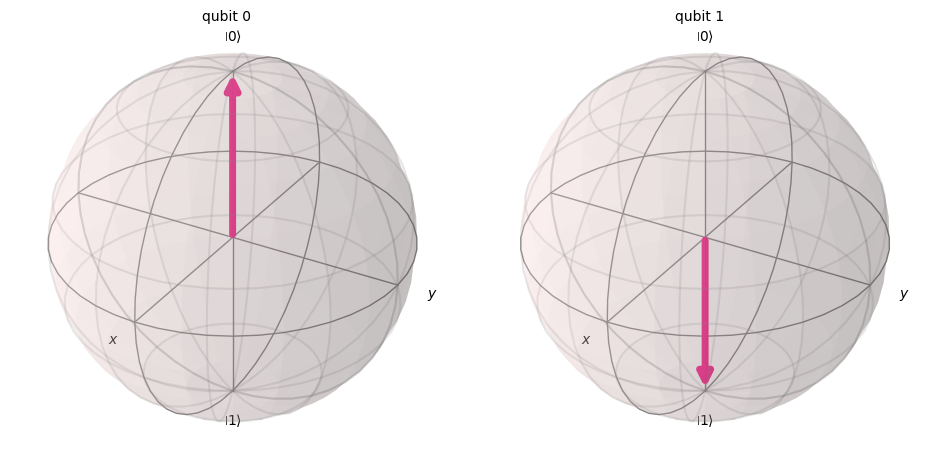

In [24]:
#Single Qubit Gates

z = sp.Matrix([[1, 0],
                [0, -1]])


for eigenvalue, _, eigenvector in z.eigenvects():
    print(f'eigen value: {eigenvalue}')
    print(f'eigen vector: {eigenvector[0]}')

qc = QuantumCircuit(2) # Use two qubits to visualize the effect of each gate

qc.z(0)  # Apply Z gate to q0
qc.x(1)  # Prepare |1> state for q1
qc.z(1)  # Apply Z gate to |1>

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


## Z gate


$ Z|0> = |0> eigenvalue = 1 $ 

$ Z|1> = -|1> eigenvalue = -1 = e^{i\pi} $

## Controlled Z gate

control = 0 → don't apply Z

control = 1 → apply Z

### Truth table

| Control | Target | CZ result |
| --- | --- | --- |
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | -1 |

Input:  |00>


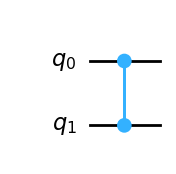

Output: |00>
----------------------------------------
Input:  |01>


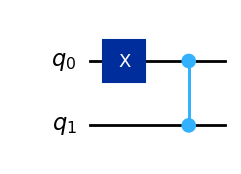

Output: |01>
----------------------------------------
Input:  |10>


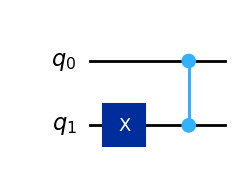

Output: |10>
----------------------------------------
Input:  |11>


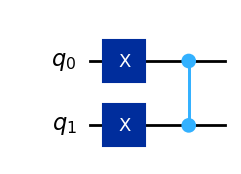

Output: -|11>
----------------------------------------


In [29]:
states = ['00', '01', '10', '11']

for state in states:
    qc = QuantumCircuit(2)

    # Prepare input state
    for qubit, bit in enumerate(reversed(state)):
        if bit == '1':
            qc.x(qubit)

    # Apply CZ
    qc.cz(0, 1)

    output = Statevector.from_instruction(qc)

    # Get amplitude
    amplitude = output.to_dict()[state]

    # Braket notation
    if amplitude == 1:
        output_braket = f'|{state}>'
    elif amplitude == -1:
        output_braket = f'-|{state}>'

    print(f'Input:  |{state}>')
    display(qc.draw('mpl'))
    print(f'Output: {output_braket}')
    print('-' * 40)

## When the control qubit is in superposition

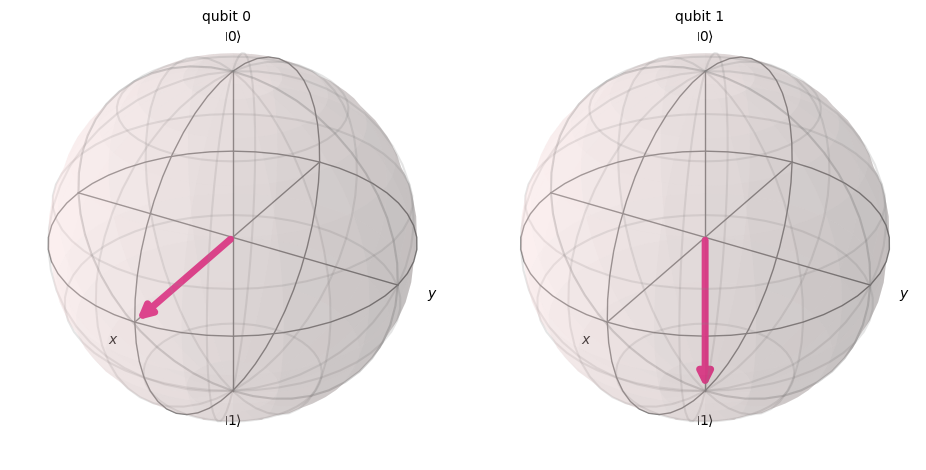

In [37]:
qc = QuantumCircuit(2)

qc.h(0)
qc.x(1)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


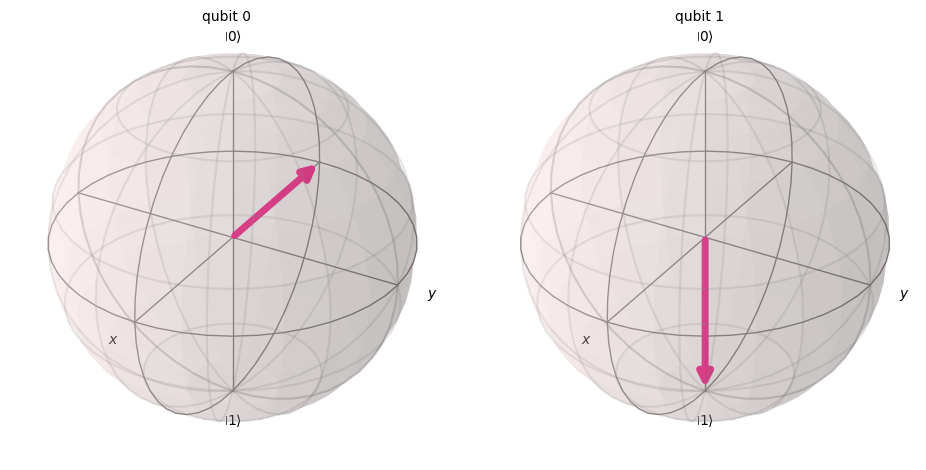

In [44]:
qc.cz(0,1)

state = Statevector.from_instruction(qc)

plot_bloch_multivector(state)


#### Something intersting happend : the target remains |1>, while the control changes from |+> to |->